# Лабораторная работа №1

## Базовый конвейер ML: от данных до модели классификации

### **Задание: Построить и сравнить три модели для прогнозирования оттока клиентов телеком-компании.**

**Импорты нужных библиотек**

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

**Разбор данных**

In [60]:
df = pd.read_csv('telecom_churn.csv')

print("Информация о датасете:")
df.info()

print("\nПроверка на наличие пропусков:")
print(df.isnull().sum())

print("\nРаспределение целевой переменной Churn:")
print(df['Churn'].value_counts())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charg

**Подготовка данных к обучению**

In [61]:
X = df.drop('Churn', axis=1)
Y = df['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

**Обучение и проверка модели**

In [62]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Neighbors': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ]
    )
    
    pipeline.fit(X_train, Y_train)
    Y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(Y_test, Y_pred)
    results[name] = acc
    print(f"Accuracy ({name}): {acc:.4f}")

Accuracy (Logistic Regression): 0.8573
Accuracy (Decision Tree): 0.9137
Accuracy (K-Neighbors): 0.8885


**Анализ результатов**

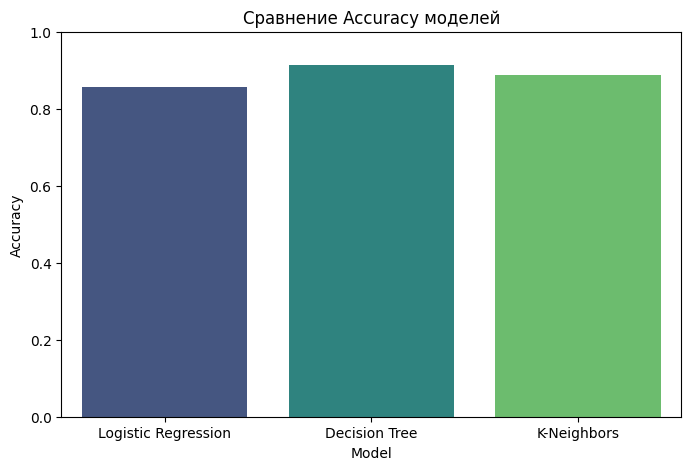


Наилучшая модель: Decision Tree

Матрица ошибок для лучшей модели:
[[675  34]
 [ 31  94]]

Ошибочно предсказаны как ушедшие (False Positives): 34
Ошибочно предсказаны как лояльные (False Negatives): 31


In [63]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Сравнение Accuracy моделей')
plt.ylim(0, 1)
plt.show()

best_model_name = max(results, key=results.get)
print(f"\nНаилучшая модель: {best_model_name}")

best_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', models[best_model_name])
    ]
)
best_pipeline.fit(X_train, Y_train)
Y_pred_best = best_pipeline.predict(X_test)

conf_matrix = confusion_matrix(Y_test, Y_pred_best)
print("\nМатрица ошибок для лучшей модели:")
print(conf_matrix)

false_positives = conf_matrix[0, 1]
false_negatives = conf_matrix[1, 0]

print(f"\nОшибочно предсказаны как ушедшие (False Positives): {false_positives}")
print(f"Ошибочно предсказаны как лояльные (False Negatives): {false_negatives}")

---

# Лабораторная работа №2

## Настройка и улучшение ML-модели

### **Задание: Выявить слабые места лучшей модели с прошлого занятия и провести ее комплексную оптимизацию.**

Отчет о классификации базовой модели (Decision Tree):


              precision    recall  f1-score   support

       False       0.96      0.95      0.95       709
        True       0.73      0.75      0.74       125

    accuracy                           0.92       834
   macro avg       0.85      0.85      0.85       834
weighted avg       0.92      0.92      0.92       834



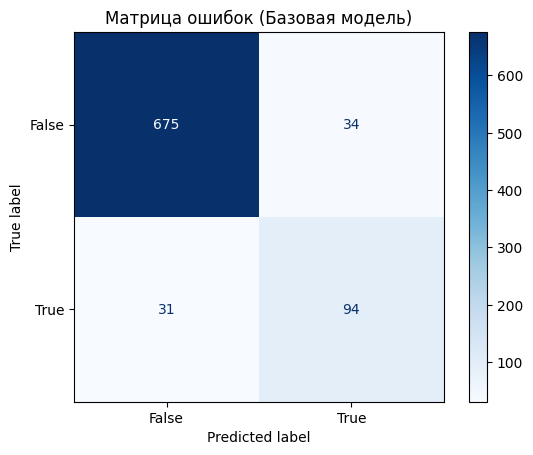

In [64]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

Y_pred_base = best_pipeline.predict(X_test)

print("Отчет о классификации базовой модели (Decision Tree):")
print(classification_report(Y_test, Y_pred_base))

disp = ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred_base, cmap='Blues')
disp.ax_.set_title('Матрица ошибок (Базовая модель)')
plt.show()

В наших данных наблюдается сильный дисбаланс: лояльных клиентов (False) почти в 6 раз больше, чем ушедших (True). Как мы уже обсуждали, для бизнеса критичнее ошибка False Negative (пропуск уходящего клиента). Поэтому наша цель оптимизации — повысить полноту (Recall) для класса ушедших клиентов (True) хотя бы до 0.7, чтобы выявлять больше людей, планирующих отказаться от услуг связи.

**Создание надежного конвейера**

In [65]:
dt_balanced = DecisionTreeClassifier(class_weight='balanced')

pipeline_cv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt_balanced)
])

**Системный поиск лучших параметров**

In [66]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': [10, 20, 50],
    'classifier__criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=pipeline_cv,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший F1-score на кросс-валидации: {grid_search.best_score_:.4f}")

Лучшие параметры: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10}
Лучший F1-score на кросс-валидации: 0.6933


**Финальная оценка и интерпретация**

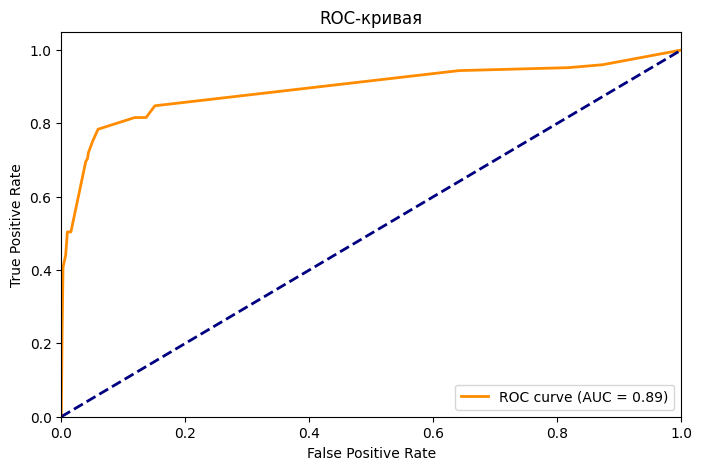

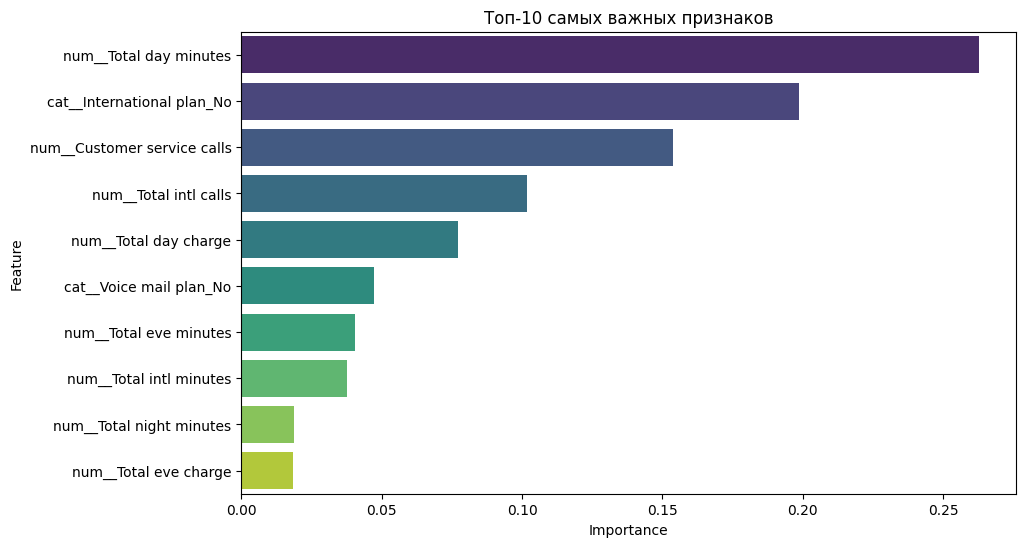

Сравнение ключевых метрик:
         Метрика  Базовая модель  Оптимизированная модель
        Accuracy        0.922062                 0.917266
Precision (True)        0.734375                 0.700000
   Recall (True)        0.752000                 0.784000
 F1-score (True)        0.743083                 0.739623


In [67]:
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score

best_model_tuned = grid_search.best_estimator_

Y_pred_tuned = best_model_tuned.predict(X_test)
Y_proba_tuned = best_model_tuned.predict_proba(X_test)[:, 1]

acc_tuned = accuracy_score(Y_test, Y_pred_tuned)
prec_tuned = precision_score(Y_test, Y_pred_tuned)
rec_tuned = recall_score(Y_test, Y_pred_tuned)
f1_tuned = f1_score(Y_test, Y_pred_tuned)

fpr, tpr, thresholds = roc_curve(Y_test, Y_proba_tuned)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.show()

feature_names = best_model_tuned.named_steps['preprocessor'].get_feature_names_out()
importances = best_model_tuned.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Топ-10 самых важных признаков')
plt.show()

comparison_data = {
    'Метрика': ['Accuracy', 'Precision (True)', 'Recall (True)', 'F1-score (True)'],
    'Базовая модель': [
        accuracy_score(Y_test, Y_pred_base),
        precision_score(Y_test, Y_pred_base),
        recall_score(Y_test, Y_pred_base),
        f1_score(Y_test, Y_pred_base)
    ],
    'Оптимизированная модель': [acc_tuned, prec_tuned, rec_tuned, f1_tuned]
}

comparison_df = pd.DataFrame(comparison_data)
print("Сравнение ключевых метрик:")
print(comparison_df.to_string(index=False))